In [1]:
#import librarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1. import database / data

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """ 
    SELECT name
    FROM sqlite_master
    WHERE type='table';
"""
tables = pd.read_sql(sql_query,conn)
print(tables['name'].tolist())

#create data frame for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

['db_customer', 'db_subscription', 'db_support']
Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# print table and column names 

conn = sqlite3.connect('customer_churn.db') 

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
#2 data Cleaning

In [6]:
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [8]:
# a. rename col - name
# b. drop columns - interest and pincode
# c. change data type - DOB
# d. data standardization - gender
# e. fix missing values - country

In [9]:
# a. rename col - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [10]:
# b. drop columns - interest and pincode

#df_db_customer.drop(df_db_customer.columns[6:], axis=1) 
#df_db_customer.drop(df_db_customer.columns[-2:], axis=1) 

df_db_customer.drop(columns=['interests','pincode'], inplace= True)


In [11]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [12]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [13]:
# c. change data type - DOB

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [14]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [15]:
# d. data standardization - gender

#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [17]:
# e. fix missing values - country

#df_db_customer['country'].fillna('Khali Hai')
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [18]:
# country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [20]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [21]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [22]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [23]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [24]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [25]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [26]:
df_db_support.drop(columns=['col_1','comment'], inplace=True)

In [27]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [28]:
# 3 feature engineering and data analysis

In [29]:
# create new column using existing column  - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [30]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
# first fix support table duplicates then merge

df = (df_db_subscription
        .merge(df_db_customer, on = 'customerid', how='left')
        .merge(df_db_support, on = 'customerid', how='left'))

In [32]:
df_db_subscription.shape

(21, 12)

In [33]:
df.shape

(23, 20)

In [34]:
df_db_subscription['customerid'].nunique()

21

In [35]:
df_db_customer['customerid'].nunique()

21

In [36]:
df_db_support['customerid'].nunique()

7

In [37]:
df_db_support['customerid'].size

9

In [38]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [39]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [40]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [41]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [42]:
df_db_support['customerid'].nunique()

7

In [43]:
df_db_support['customerid'].size

7

In [44]:
# merge df

df = (df_db_subscription
        .merge(df_db_customer, on = 'customerid', how='left')
        .merge(df_db_support, on = 'customerid', how='left'))

In [45]:
df.shape

(21, 21)

In [46]:
df.to_csv('exported_churn_data.csv', index=False)

In [47]:
# data analysis

In [48]:
# 1. churn rate

In [49]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [50]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [51]:
# 2. Retention Rate

retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [52]:
# 3. churn by plan type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [53]:
# 4. a. churn by state + sum(revenue) & count of users

churn_by_state = df.groupby('state').agg(total_revenue = ('monthly_charges','sum'),
                                         total_users = ('customerid','count')).reset_index()
print(churn_by_state)

           state  total_revenue  total_users
0          Delhi          52.96            4
1      Karnataka          20.98            2
2      Kathmandu          20.98            2
3    Maharashtra          50.97            3
4      Meghalaya          42.97            3
5       Nagaland          22.99            1
6      Rajasthan          36.98            2
7      Telangana          30.98            2
8  Uttar Pradesh         115.98            2


In [54]:
# 4. b. churn by subscription type + sum(revenue) & count of users

churn_by_subscription = df.groupby('subscription_type').agg(total_revenue = ('monthly_charges','sum'),
                                                            total_users = ('customerid','count')).reset_index()
print(churn_by_subscription)


  subscription_type  total_revenue  total_users
0           Organic         145.91            9
1              Paid         174.94            6
2          Refferal          74.94            6


In [55]:
# 5. ARPU - Avg Revenue Per User

arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [56]:
# homewok - caculated customer age

today = pd.Timestamp.today()
df['age'] = (today - df['dob']).dt.days // 365

In [57]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,44
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,48
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,25
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,36
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0,37
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0,50
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN,27
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN,41
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN,32


In [58]:
# 6. Avg Customer Tenure
# count of days user has used our service : cancellation date else current date

today = pd.Timestamp.today() 

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure))

Avg Tenure (Days) =  1544


In [59]:
# 7. Revenue at risk - revenue lost from churned user

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =",revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [60]:
# 8. Escalation Rate

escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Escalation Rate =", round(escalation_rate,2),"%")

Escalation Rate = 19.05 %


In [61]:
# 9. Avg Complaint Per User

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User =", round(avg_complaints,2))

Avg Complaints Per User = 0.43


In [62]:
# 10. Correlation Escalaton vs Churn

df['escalations'] = np.where(df['escalations'] == 'Y',1,0) # encoding string to integer type 
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation Between Escalation vd Churn is =", round(correlation,2))

Correlation Between Escalation vd Churn is = 0.77


In [63]:
# 11. reate a column "churn_risk" using existing col - churn_score

conditions = [
    (df['churn_score'] <50),
    (df['churn_score'] >=50) & (df['churn_score'] <70),
    (df['churn_score'] >70)
]

risk = ['low','mid','high']

df['churn_risk'] = np.select(conditions,risk,default='unknown')

In [64]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,mid,62
17,low,27
18,high,99
19,low,7
20,low,47


In [65]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [66]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,44,2016.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,30,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,48,1401.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,25,2691.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,36,419.0,high


In [67]:
# 4. Visualization using Matplotlib

In [68]:
df_visual = df.copy()

In [69]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk'],
      dtype='object')

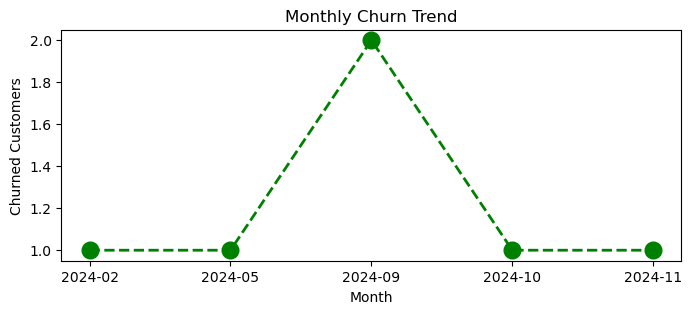

In [70]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

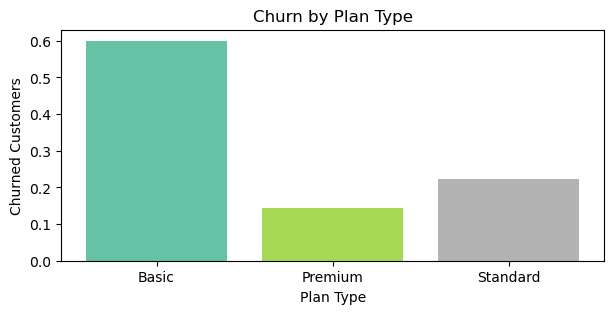

In [71]:
# 4.2 Churn by Plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

#colors = ['red','blue','yellow']
colors = plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
plt.figure(figsize=(7,3))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churned Customers')
plt.show()

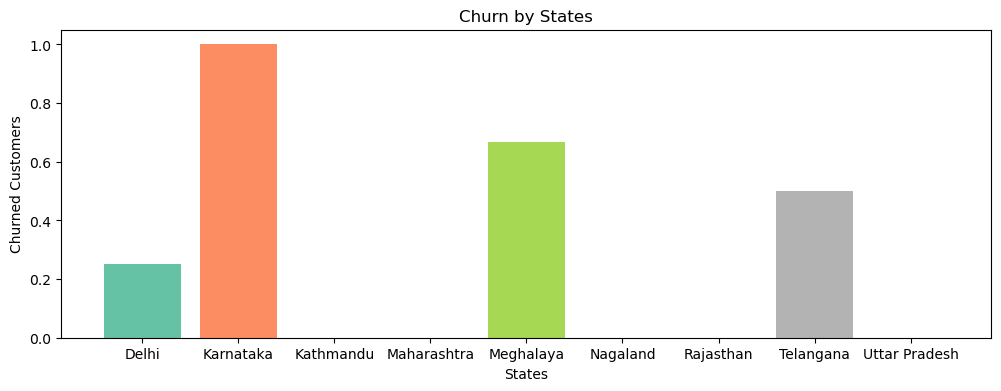

In [72]:
# 4.3 Churn by States

churn_state = df_visual.groupby('state')['churn_flag'].mean()

#colors = ['red','blue','yellow']
colors = plt.cm.Set2(np.linspace(0,1, len(churn_state)))
 
plt.figure(figsize=(12,4))
plt.ylabel('Churned Customers')

plt.bar(churn_state.index, churn_state.values, color = colors)
plt.title('Churn by States')
plt.xlabel('States')
plt.show()

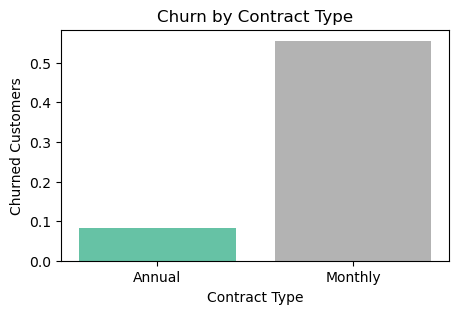

In [73]:
# 4.4 Churn by Contract Type

churn_contract_type = df_visual.groupby('contract_type')['churn_flag'].mean()

#colors = ['red','blue','yellow']
colors = plt.cm.Set2(np.linspace(0,1, len(churn_contract_type)))
 
plt.figure(figsize=(5,3))

plt.bar(churn_contract_type.index, churn_contract_type.values, color = colors)
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churned Customers')
plt.show()

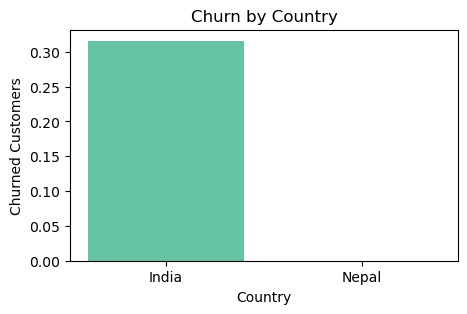

In [74]:
# 4.5 Churn by Country

churn_country = df_visual.groupby('country')['churn_flag'].mean()

#colors = ['red','blue','yellow']
colors = plt.cm.Set2(np.linspace(0,1, len(churn_country)))
 
plt.figure(figsize=(5,3))

plt.bar(churn_country.index, churn_country.values, color = colors)
plt.title('Churn by Country')
plt.xlabel('Country')
plt.ylabel('Churned Customers')
plt.show()

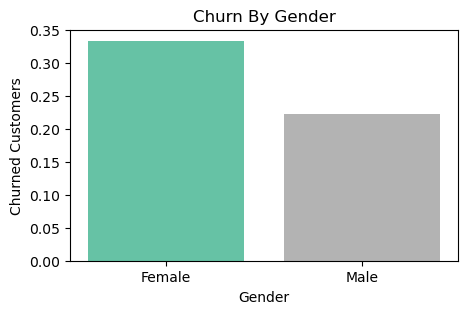

In [75]:
# 4.6 Churn By Gender

churn_gender = df_visual.groupby('gender')['churn_flag'].mean()

#colors = ['red','blue','yellow']
colors = plt.cm.Set2(np.linspace(0,1, len(churn_gender)))
 
plt.figure(figsize=(5,3))

plt.bar(churn_gender.index, churn_gender.values, color = colors)
plt.title('Churn By Gender')
plt.xlabel('Gender')
plt.ylabel('Churned Customers')
plt.show()

In [76]:
# Visulazation using Seaborn

In [77]:
# Encoding - Convert str to numric value so that we can find corr between features

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [78]:
df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations',]].head() 

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [101]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [80]:
import warnings
warnings.filterwarnings("ignore")

In [81]:
# incorrect method of encoding - as numbers are not assigned based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations',]]

categorical_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

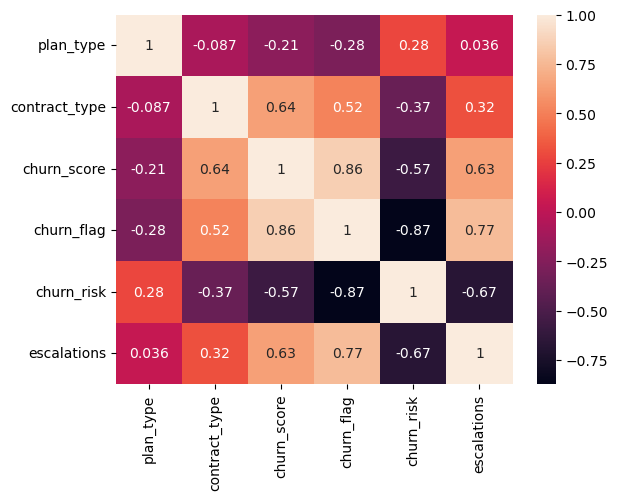

In [82]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)

In [83]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'mid'], dtype=object)

In [84]:
# Correct method of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations',]]

order_mapping = {
    'plan_type' : ['Basic','Standard','Premium'], 
    'contract_type' : ['Monthly', 'Annual'], 
    'churn_risk' : ['low', 'mid', 'high']
}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order, ordered=True).codes

In [85]:
df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations',]].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [86]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

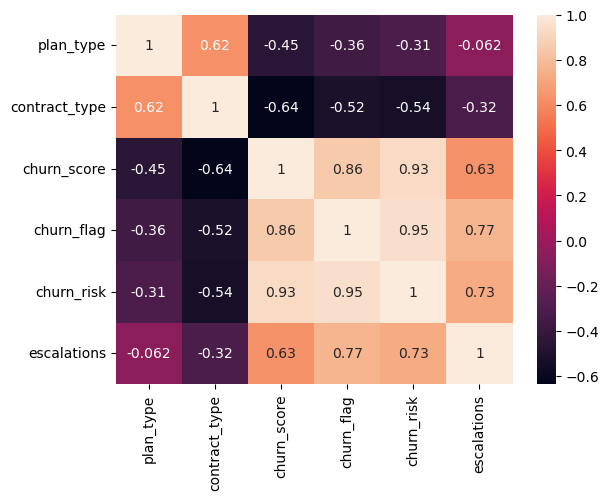

In [87]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)

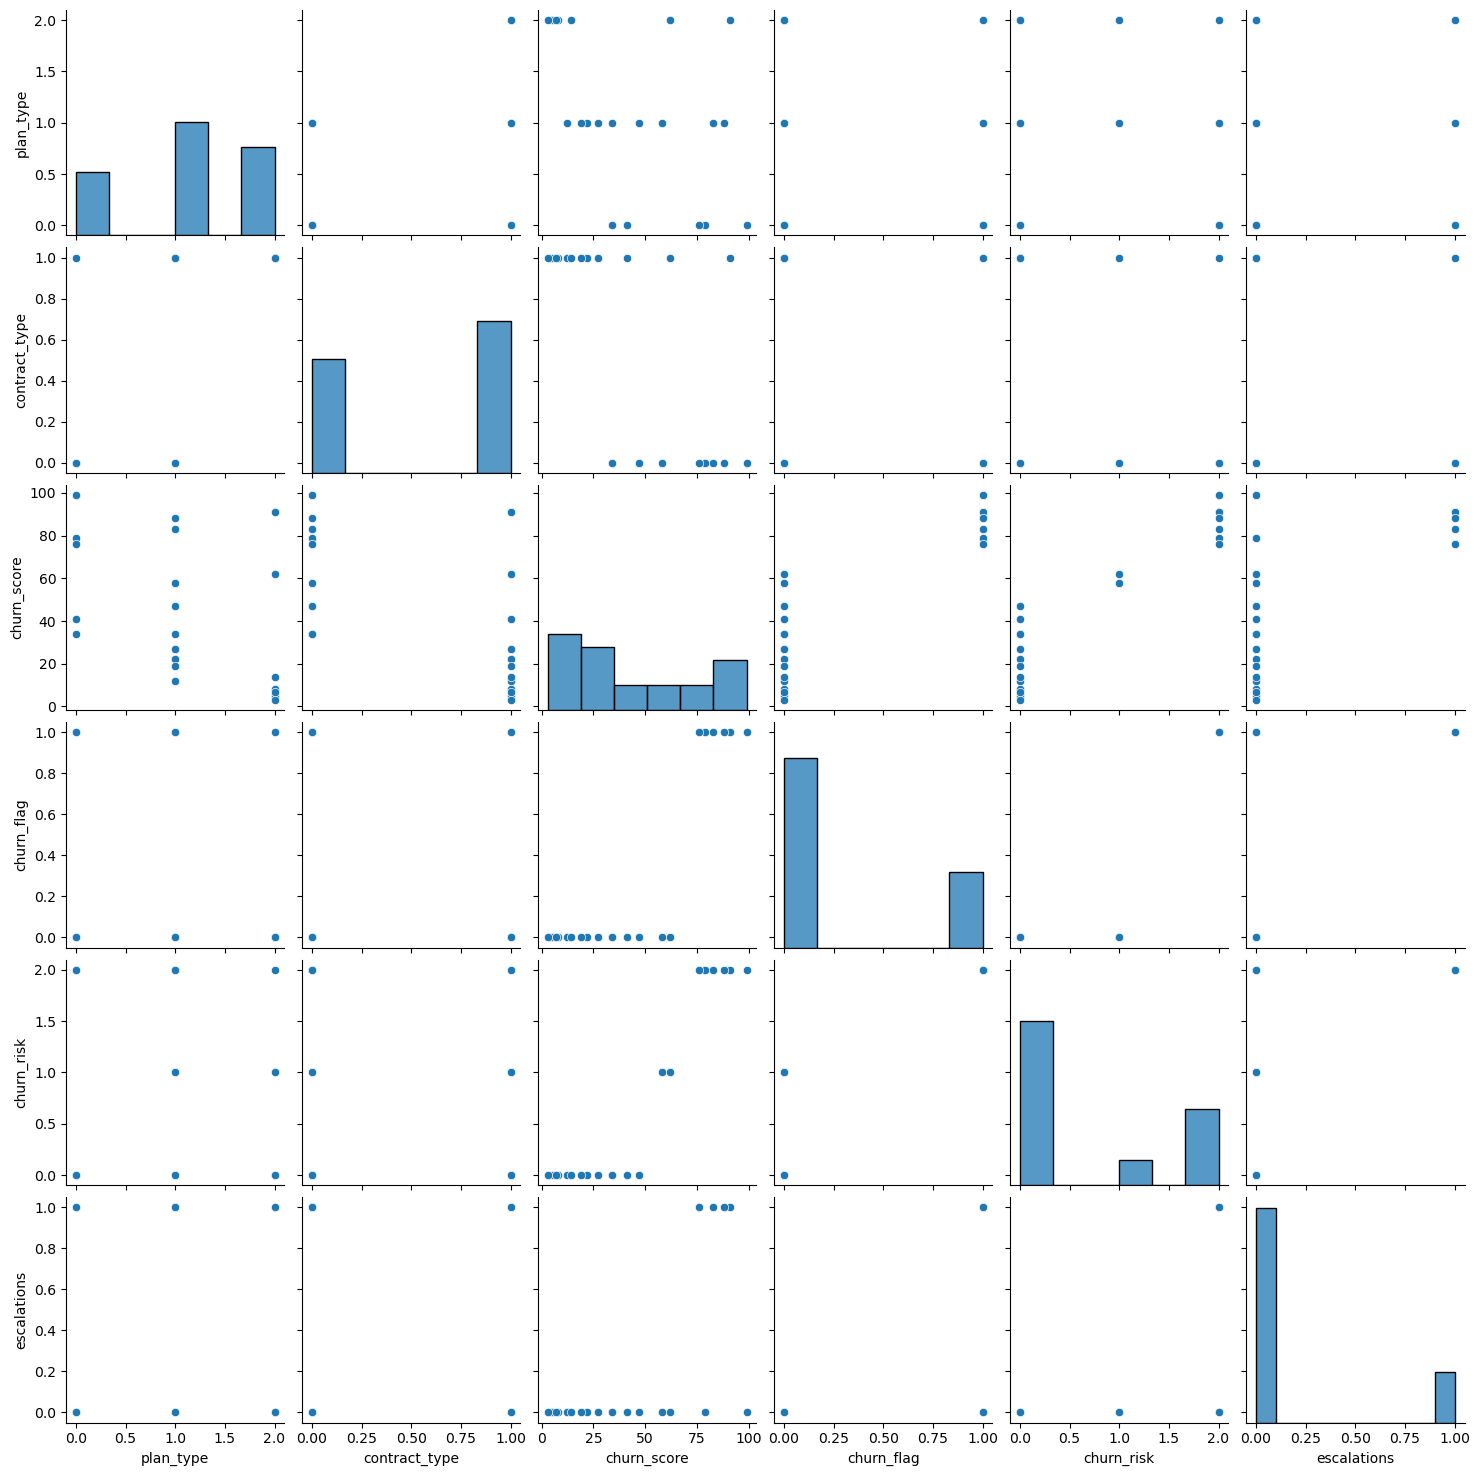

In [88]:
# pairplot - rlationship in a dataset

sns.pairplot(df_encoded)

In [89]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

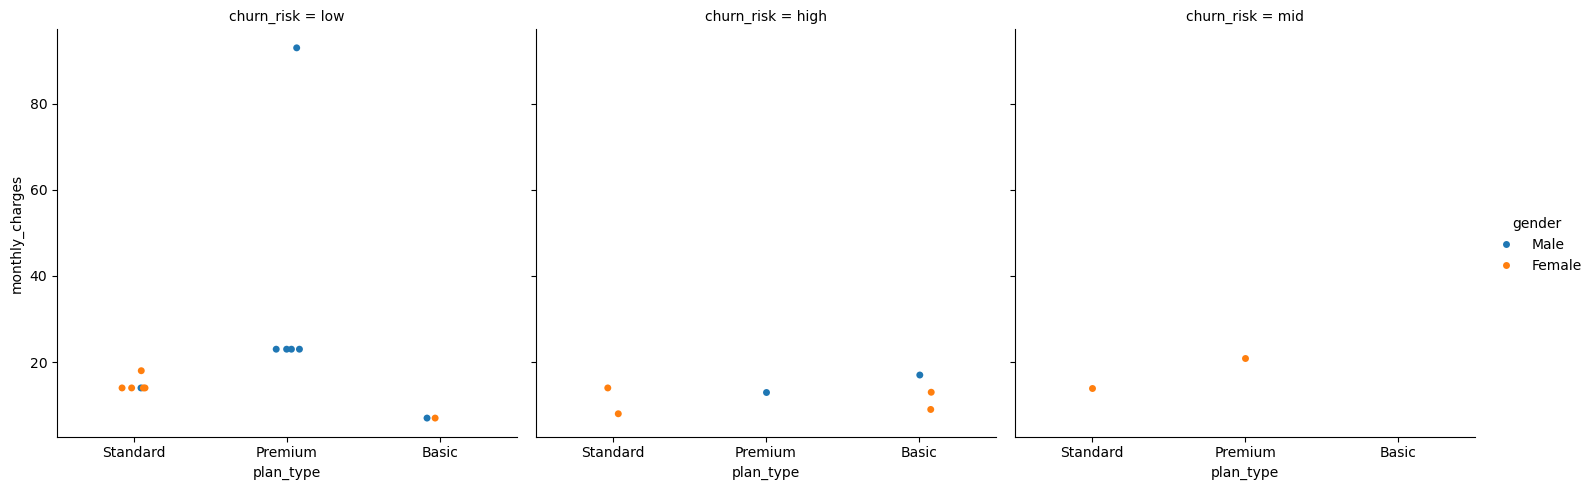

In [90]:
# categorical plot/facegrid plot - multi dimension comparison

sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

In [91]:
# Pivot Table

In [92]:
pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc= 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [93]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [94]:
pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc= {
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag':'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [95]:
# working with SQL in Python (pandas)

In [96]:
# create DB in SQL

conn = sqlite3.connect('test_database.sqlite')

# table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

#commit and save
conn.commit()

In [97]:
# insert data
cursor = conn.cursor()

# write SQl query to insert records in sql table
cursor.execute(
    """ 
        INSERT INTO users VALUES
            ('Madhav','India',5000),
            ('Rishab','Germany',2500),
            ('Vishaka','India',3500)
    """
)

# commit and save
conn.commit()

print("Data Inserted Successfully")

Data Inserted Successfully


In [98]:
# check inserted data in table

conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users"""

df_results = pd.read_sql(query,conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishab,Germany,2500
2,Vishaka,India,3500


In [99]:
# aggregation

query = """ 
        SELECT country , sum(budget) as total_budget
        FROM users 
        GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [100]:
# always close the conn with DB once the task is over
conn.close()